### Метод контурных интегралов

In [36]:
import numpy as np
import matplotlib.pyplot as plt

#### №1 Задание функции

Заданная функция

Для около правильного последнего коэффициента необходимо n > 500000 в прямоугольнике (-10, 10)

In [37]:
def f(z):
    return z ** 4 - 9 * z ** 3 - z ** 2 + 2 * z + 3

Производная функции

In [38]:
def f_derivative(z):
    return 4 * z ** 3 - 27 * z ** 2 - 2 * z + 2

#### №2 Нахождение интеграла

Интеграл по формуле трапеций

In [39]:
def trapezoidal_integral_on_path(f, z_path):
    fz = f(z_path)
    dz = np.diff(z_path)
    integrand = 0.5 * (fz[:-1] + fz[1:])
    return np.sum(integrand * dz)

Тест формулы

In [40]:
f_test = lambda x: 2 * x
x_test = np.linspace(1, 3, 100)
result_test = trapezoidal_integral_on_path(f_test, x_test)
# x ** 2 | (1, 3) = 9 - 1
print(result_test)
x_test = np.linspace(3, 1, 100)
result_test = trapezoidal_integral_on_path(f_test, x_test)
print(result_test)

8.0
-7.999999999999998


Контурынй интеграл по прямоугольнику

$$ 2πi\int_γ{z^p\frac{f'(z)}{f(z)}} $$

In [41]:
def contour_integral_rectangle(f, f_derivative, p, x0, y0, x1, y1, n):
    integrand_f = lambda z: (z**p) * f_derivative(z) / f(z)
    # from (x0, y0) to (x1, y0)
    x = np.linspace(x0, x1, n + 1)
    z1 = x + 1j * y0
    s1 = trapezoidal_integral_on_path(integrand_f, z1)

    # from (x1, y0) to (x1, y1)
    y = np.linspace(y0, y1, n + 1)
    z2 = x1 + 1j * y
    s2 = trapezoidal_integral_on_path(integrand_f, z2)

    # from (x1, y1) to (x0, y1)
    x = np.linspace(x1, x0, n + 1)
    z3 = x + 1j * y1
    s3 = trapezoidal_integral_on_path(integrand_f, z3)

    # from (x0, y1) to (x0, y0)
    y = np.linspace(y1, y0, n + 1)
    z4 = x0 + 1j * y
    s4 = trapezoidal_integral_on_path(integrand_f, z4)

    return (s1 + s2 + s3 + s4) / (2j * np.pi)

Вычисление коэффициентов полинома

In [57]:
def calcuclate_coefficiences(f, f_derivative, x0, y0, x1, y1, n, k_max=None):
    k = k_max if not k_max is None else int(np.round(contour_integral_rectangle(f, f_derivative, 0, x0, y0, x1, y1, n).real))
    print(int(np.round(contour_integral_rectangle(f, f_derivative, 0, x0, y0, x1, y1, n).real)))
    s = np.zeros(k, dtype=complex)

    for i in range(k):
        s[i] = contour_integral_rectangle(f, f_derivative, i + 1, x0, y0, x1, y1, n)

    coeffs = np.zeros(k, dtype=complex)
    coeffs[0] = -s[0]
    for i in range(1, k):
        temp = 0
        for j in range(i):
            temp += coeffs[i - j - 1] * s[j]
        coeffs[i] = -(temp + s[i]) / (i + 1)

    return coeffs.real

#### №3 Нахождение корней

Гессенберговый вид матрицы
$$
\begin{pmatrix}
  * & * & * \\
  a & * & * \\
  0 & b & *
\end{pmatrix}
$$

https://people.inf.ethz.ch/arbenz/ewp/Lnotes/chapter4.pdf

In [43]:
def qr_hessenberg_decomposition(H : np.array):
    n = H.shape[0]
    Q = np.eye(n)
    R = H.copy()

    for i in range(n - 1):
        a = R[i, i]
        b = R[i + 1, i]
        if np.isclose(b, 0.0):
            continue
        r = np.sqrt(a ** 2 + b ** 2)
        c = a / r
        s = -b / r

        G = np.array([[c, -s],
                     [s, c]])
        R[i:i+2, i:n] = G @ R[i:i+2, i:n]
        Q[:, i:i+2] = Q[:, i:i+2] @ G.T
        
    return Q, R

$$ λ^2−(a+d)λ+(ad−bc)=0 $$

$$ δ=(a−d)/2 $$

$$ λ=d−\frac{​sign(δ)⋅bc​}{∣δ∣+\sqrt{δ^2+bc}} $$


In [44]:
def wilkinson_shift(a, b, c, d):
    delta = (a - d) / 2
    sign = np.sign(delta) if delta != 0 else 1
    return d - (sign * b * c) / (abs(delta) + np.sqrt(abs(delta ** 2 + b * c)))


In [45]:
def qr_algorithm(C):
    A = C.copy()
    Q, R = qr_hessenberg_decomposition(A)
    n = A.shape[0]
    j = n - 1
    eigenvalues = []
    while j >= 0:
        if j == 0 or np.isclose(A[j, j - 1], 0.0):
            eigenvalues.append(A[j, j])
            j -= 1
            continue
        
        a, b = A[j-1, j-1], A[j-1, j]
        c, d = A[j, j-1], A[j, j]
        
        if j == 1 or np.isclose(A[j - 1, j - 2], 0.0):
            trace = a + d
            det = a*d - b*c
            disc = trace**2 - 4*det
            sqrt_disc = np.sqrt(disc + 0j)
            eigenvalues.append((trace + sqrt_disc) / 2)
            eigenvalues.append((trace - sqrt_disc) / 2)
            j -= 2
            continue

        v = wilkinson_shift(a, b, c, d)
        Q, R = qr_hessenberg_decomposition(A[:j+1, :j+1] - v * np.eye(j+1))
        A[:j+1, :j+1] = R @ Q + v * np.eye(j+1)

        for i in range(1, j):
            if np.isclose(A[i, i-1], 0.0):
                A[i, i-1] = 0.0

    return eigenvalues


Сопровождающая матрица C =
$$
\begin{pmatrix}
  0 & 0 & -c_1 \\
  1 & 0 & -c_2 \\
  0 & 1 & -c_3
\end{pmatrix}
$$

In [ ]:
def companion(coeffs):
    n = len(coeffs)
    C = np.zeros((n, n))
    C[1:, :-1] = np.eye(n - 1)
    C[:, -1] = -coeffs[::-1]
    return C

Прямоугольник, в котором необходимо найти корни

In [46]:
x0, y0 = -10, -10
x1, y1 = 10, 10
n = 500000

4
Корни:
9.08172048928532
0.7906699486163895
(-0.43619656309632393+0.49161284758161816j)
(-0.43619656309632393-0.49161284758161816j)


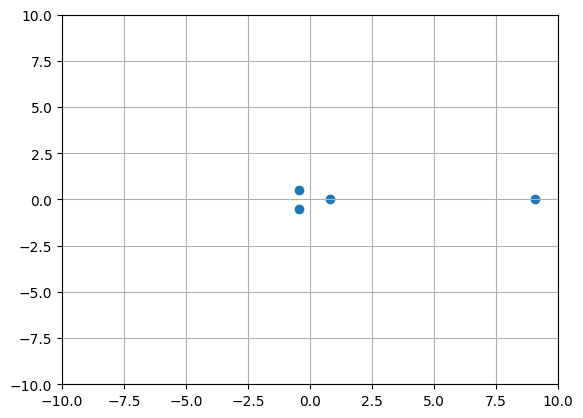

In [81]:
coeffs = calcuclate_coefficiences(f, f_derivative, x0, y0, x1, y1, n)
C = companion(coeffs)

roots = qr_algorithm(C)
print("Корни:")
print(*roots, sep="\n")

plt.scatter(np.real(roots), np.imag(roots))
plt.grid()
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()

#### №4 Пример с другой функцией

In [86]:
def f_2(z):
    return np.sin(z) - z / 2

def f_2_derivative(z):
    return np.cos(z) - 0.5

In [91]:
x0, x1 = -10, 10
y0, y1 = -10, 10
n = 10000

7
Корни:
(-7.581799174080325+2.046716369644141j)
(-7.581799174080325-2.046716369644141j)
-1.89548942186571
-2.795125577796957e-12
1.8954893979916687
(7.581799186018766+2.0467164309083774j)
(7.581799186018766-2.0467164309083774j)


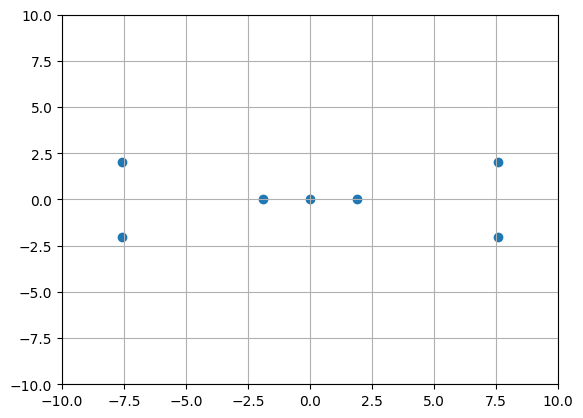

In [92]:
coeffs = calcuclate_coefficiences(f_2, f_2_derivative, x0, y0, x1, y1, n)
C = companion(coeffs)

roots = qr_algorithm(C)
print("Корни:")
print(*roots, sep="\n")

plt.scatter(np.real(roots), np.imag(roots))
plt.grid()
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()